# Phase 4: Anomaly and Outlier Detection

Home Credit Default Risk, KDD Phase 4.

No single detector sees every kind of outlier, so this phase runs six signals that look at the data from different angles and then asks how many of them agree:

1. IQR (univariate): flags a value outside the whiskers of its own column. Robust on skewed data, calibrated per column from that column's own distribution rather than a fixed rule, but blind to combinations.
2. Z-score (univariate): flags a value far from its column mean, with the cut-off also calibrated per column instead of a fixed number of standard deviations. A sensitive complement to IQR, also blind to combinations.
3. Mahalanobis distance (multivariate, statistical): flags a row whose combination of values is far from the bulk once correlations are accounted for, even when every column alone looks fine. Uses a robust covariance (MCD) so the outliers cannot hide the ellipsoid they distort.
4. Isolation Forest (multivariate, structural): tree-based, no distribution assumption, catches non-linear pockets and interactions that a covariance ellipsoid cannot describe.
5. Local Outlier Factor (multivariate, local density): flags a row whose neighbourhood is far sparser than its neighbours' own neighbourhoods, a relative, local comparison rather than one fixed density rule for the whole portfolio.
6. DBSCAN noise from Phase 2 (multivariate, global density): points that sit in no dense region of the UMAP embedding, an independent cross-check from a different phase, using one fixed density rule for everyone.

The more of these agree, the more confident we are. Each high-confidence anomaly then gets two labels, by theory scope and by business type, plus a short recommendation grounded in that record's own data.

Input: `datasets/final/features_clustering.csv` (Phase 1) and `datasets/final/cluster_labels.csv` (Phase 2, including the DBSCAN outlier flag).

Outputs land in `results/phase4_anomaly/`: the per-method outlier tables, the combined cross-method table, the summary, the per-record investigation CSV, and the plots. The written report lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.stats.stattools import medcouple

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = evaluate every application (full dataset)
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # outlier if flagged in >=3 columns

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
labels = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns and c in features.columns])
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_merged) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'SK_ID_CURR', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

id_cols = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_merged.columns]
df_numeric = pd.concat([df_merged[id_cols].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'\nNumeric features: {df_features.shape[1]}')
print(f'Saved data_numeric.csv & data_with_labels.csv')

Loading features ...


  features: (356255, 49)
  labels  : (356255, 5)
  merged  : (356255, 53)



Numeric features: 47
Saved data_numeric.csv & data_with_labels.csv


## 2. Univariate statistical outliers: IQR and Z-score

These two look at one column at a time, and only at genuinely continuous fields (income, credit amount, annuity, days employed, external scores, and the like). Binary flags and few-valued ordinals are deliberately excluded here: if three out of every four applicants share the exact same flag value, the 25th and 75th percentiles collapse onto that same value, the interquartile range becomes zero, and the classic fence then treats every applicant carrying the rarer value, for example simply not owning a car, as if their finances were extreme. That is not outlier detection, it is an artefact of applying a continuous-data rule to a categorical field.

### Why a flat multiplier, or any other textbook constant, is not enough for this data

Tukey's classic rule (Q1 - 1.5*IQR, Q3 + 1.5*IQR) assumes the bulk of the data sits roughly symmetric around its centre, and the 1.5 itself is a convention from 1977, not something derived from this portfolio. Home Credit's financial fields are not symmetric: income, credit amount, and annuity are all right-skewed by construction, since a loan or an income cannot go below zero, and the population is a large, tightly packed group of ordinary borrowers plus a long, entirely legitimate tail of higher earners and bigger loans. A fixed multiplier applied to every column punishes that tail unfairly on some columns and is too lenient on others, because it never looks at what the column itself actually does.

Two upgrades are combined here. First, the skew-adjusted boxplot rule (Hubert and Vandervieren, 2008), built on the medcouple, a robust measure of skewness bounded between -1 and 1: instead of one flat multiplier on both sides, the medcouple stretches the fence toward the side the column is expected to stretch and tightens the other side, so "normal" is defined by each column's own shape rather than by an assumption that every financial feature looks like a bell curve. Second, and this is the part that removes the last hand-picked constant, the fence multiplier itself is calibrated separately for every column: instead of reusing 1.5 everywhere, a short search finds the multiplier that makes each column flag close to a fixed, chosen share of its own values (1 percent here). This is the same principle already used for Mahalanobis later in this notebook, where the operating point is fixed empirically at the top 2.5 percent of scores instead of trusting a textbook cut-off: let the data and a deliberately chosen operating point set the threshold, not a constant borrowed from a different dataset. The result is a threshold that is genuinely learned from each column's own distribution, which is the best-practice standard for outlier thresholding on data this skewed and this uneven from one column to the next.

Z-score is kept alongside it, deliberately left on the naive, symmetry-assuming statistic (mean and standard deviation rather than median and quartiles), but its threshold is calibrated the same way, at the quantile of each column's own |z| distribution that leaves 1 percent of applicants beyond it. Calibrating both methods to the same target rate keeps the comparison fair: any remaining difference in which rows they catch now comes from the statistic itself, not from one method using a looser or tighter cut-off than the other. Where a column happens to be close to symmetric the two agree closely; where a column is heavily skewed (most of the continuous financial fields here), they diverge, and that divergence is the signal that the symmetry assumption, not a difference in strictness, is driving the gap.

One more refinement matters here, and it only shows up once the fences are actually computed: a handful of continuous columns, `EXT_SOURCE_1` among them, plus the credit-card utilisation, credit-card balance, bureau delinquency ratio, and point-of-sale delay fields, pass the nunique-above-10 screen (they carry many distinct values) yet still have Q1 equal to Q3. That happens when more than half of applicants share one exact number for a genuine business reason: no credit card means zero utilisation and zero balance, no bureau record means a zero delinquency ratio, and a bureau score that is missing for over half the portfolio is filled with the same imputed value for everyone who lacks one. With the middle half of the column collapsed onto a single point, the interquartile range is zero, and a fence built on a zero-width box would flag every applicant who differs from that shared value at all, in other words every ordinary customer who actually uses a credit card or actually has a bureau record. That is exactly the same failure mode the continuous-column restriction was meant to prevent, just one level deeper, so the same principle applies: when a column's own middle 50 percent gives no usable sense of scale, IQR abstains on that column for that row rather than manufacturing a fence out of nothing.

To avoid false alarms from a single noisy feature, a row counts as a statistical outlier only if it is flagged on at least 3 of the continuous columns.

The honest limitation stands regardless of which fence is used: both methods are blind to combinations. An applicant with a modest income and a modest loan can be perfectly ordinary on each column yet very strange together, for example when the loan is large only relative to that income. Catching those cases is the job of the multivariate methods in the sections that follow.

In [2]:
# Univariate detectors only make sense on genuinely continuous columns. A
# binary flag or a low-cardinality ordinal breaks the box-plot logic
# outright: if most applicants share one flag value, Q1 and Q3 collapse onto
# it, IQR becomes zero, and every applicant carrying the rarer value (for
# example, simply owning a car) gets flagged as "outside the fence" even
# though it is just an ordinary minority category, not a strange value. The
# same continuous-only feature set is defined once here and reused by the
# Mahalanobis and Local Outlier Factor sections below, so every statistical
# detector reads the same columns.
cont_cols = [c for c in df_numeric.columns
             if c not in ('ROW_ID', 'SK_ID_CURR') and df_numeric[c].nunique() > 10]

TARGET_FLAG_RATE = 0.01  # each column is calibrated to flag about 1% of its own values


def _skew_adjusted_flags(values, mc, iqr, q1, q3, mult):
    if mc >= 0:
        lower = q1 - mult * np.exp(-4 * mc) * iqr
        upper = q3 + mult * np.exp(3 * mc) * iqr
    else:
        lower = q1 - mult * np.exp(-3 * mc) * iqr
        upper = q3 + mult * np.exp(4 * mc) * iqr
    return (values < lower) | (values > upper)


def _calibrate_mult(values, mc, iqr, q1, q3, target_rate, lo=0.05, hi=20.0, iters=50, max_expand=20):
    """
    Binary-search the fence multiplier so this column flags close to
    target_rate of its own values, instead of reusing Tukey's 1.5 (or any
    other textbook constant) for every column regardless of how it behaves.
    A bigger multiplier always widens the fence and can only flag the same
    rows or fewer, so the flagged share is monotonic in the multiplier and
    bisection finds the calibrated value directly. This mirrors the
    empirical 97.5th-percentile cut-off used for Mahalanobis later in this
    notebook: let the data and a chosen operating point set the threshold,
    not a constant borrowed from a different dataset.

    A fixed upper search bound is not always wide enough: a column whose
    interquartile range is tiny relative to its actual spread (a ratio that
    sits within a hair's width of its own median for most applicants, with
    a long thin tail beyond it) needs a far larger multiplier before the
    fence reaches the target rate. Rather than accept whatever the search
    boundary happens to land on, which would silently leave the column
    over-flagged, the upper bound is doubled until it is demonstrably wide
    enough, then the search proceeds as normal.
    """
    rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
    expand = 0
    while rate_hi > target_rate and expand < max_expand:
        hi *= 4
        rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
        expand += 1
    for _ in range(iters):
        mid = (lo + hi) / 2
        rate = _skew_adjusted_flags(values, mc, iqr, q1, q3, mid).mean()
        if rate > target_rate:
            lo = mid
        else:
            hi = mid
    # A count-like column (a bounded number of months, refusals, and so on)
    # can only take a small number of distinct flagged-rate values, so the
    # achievable rate sometimes jumps straight past the target instead of
    # passing through it, for example from 5% at one multiplier straight to
    # 0% at the next. Returning hi rather than the midpoint keeps the
    # invariant the bisection already guarantees: hi never flags more than
    # the target rate. Landing under the target on a quantised column is
    # the safe side of that trade-off; landing over it is not.
    return hi


def flag_iqr_adjusted(df, cols, target_rate=TARGET_FLAG_RATE, mc_sample=2000, seed=42):
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    skew_report = {}
    mult_report = {}
    rng = np.random.default_rng(seed)
    for col in cols:
        vals = df[col].values
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        if iqr == 0:
            # A column can pass the nunique > 10 screen and still have
            # Q1 == Q3: a mass point covering more than half the applicants
            # (no credit card means zero utilisation, no bureau record
            # means a zero delay ratio, an imputed bureau score sits at one
            # shared value for everyone missing it). With the middle half
            # collapsed onto one number, IQR has no usable sense of scale,
            # so this column abstains rather than flagging every applicant
            # who differs at all from that shared value.
            skew_report[col] = 0.0
            mult_report[col] = None
            continue
        sample = vals if len(vals) <= mc_sample else rng.choice(vals, size=mc_sample, replace=False)
        mc = float(medcouple(sample))
        mult = _calibrate_mult(vals, mc, iqr, q1, q3, target_rate)
        flags[col] = _skew_adjusted_flags(vals, mc, iqr, q1, q3, mult)
        skew_report[col] = mc
        mult_report[col] = mult
    return flags, skew_report, mult_report


def flag_zscore(df, cols, target_rate=TARGET_FLAG_RATE):
    """
    The naive baseline is calibrated the same way: instead of the textbook
    z > 3 rule (built for a normal distribution most of these columns do
    not follow), each column's threshold is set at the quantile of its own
    |z| distribution that leaves target_rate of applicants beyond it. Both
    univariate methods now operate at the same chosen flag rate, so any
    remaining difference in which rows they catch comes from the statistic
    itself (mean and standard deviation versus median and quartiles), not
    from one method using a stricter cut-off than the other.
    """
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    thr_report = {}
    for col in cols:
        z = np.abs(stats.zscore(df[col], nan_policy='omit'))
        thr = np.quantile(z, 1 - target_rate)
        flags[col] = z > thr
        thr_report[col] = float(thr)
    return flags, thr_report


if SAMPLE_SIZE is None:
    sample = df_numeric.copy().reset_index(drop=True)   # full dataset
else:
    sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR'] if c in sample.columns])

print(f'Sample: {len(sample):,} rows x {feat_sample.shape[1]} features')
print(f'Univariate detectors run on {len(cont_cols)} continuous columns, each calibrated to flag '
      f'about {TARGET_FLAG_RATE*100:.0f}% of its own values; '
      f'{feat_sample.shape[1] - len(cont_cols)} binary/ordinal/frequency columns are left to '
      f'Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.')

print('Running skew-adjusted IQR with a calibrated, per-column fence ...')
t0 = time.time()
iqr_flags, skew_report, mult_report = flag_iqr_adjusted(feat_sample, cont_cols)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')
most_skewed = sorted(skew_report.items(), key=lambda kv: abs(kv[1]), reverse=True)[:5]
print('  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:')
for col, mc in most_skewed:
    mult_txt = f'{mult_report[col]:.2f}' if mult_report[col] is not None else 'n/a (zero-width box, abstains)'
    print(f'    {col:32s} MC = {mc:+.3f}   calibrated mult = {mult_txt}')

print('Running Z-score with a calibrated, per-column threshold (naive baseline) ...')
t0 = time.time()
z_flags, z_thr_report = flag_zscore(feat_sample, cont_cols)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

print(f'\n--- Statistical Summary ---')
print(f'  IQR outliers (skew-adjusted, calibrated) : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score outliers (naive, calibrated)     : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Statistical (any)                        : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods                             : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 continuous features triggering the adjusted IQR fence:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 356,255 rows x 47 features
Univariate detectors run on 35 continuous columns, each calibrated to flag about 1% of its own values; 12 binary/ordinal/frequency columns are left to Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.
Running skew-adjusted IQR with a calibrated, per-column fence ...


  Done in 1.9s
  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:
    CNT_CHILDREN                     MC = +1.000   calibrated mult = 0.10
    OWN_CAR_AGE                      MC = +1.000   calibrated mult = 0.59
    PREV_REFUSED_COUNT               MC = +1.000   calibrated mult = 0.35
    INST_PAYMENT_RATIO_MEAN          MC = -1.000   calibrated mult = 990.69
    CC_MONTHS_COUNT                  MC = +1.000   calibrated mult = 0.63
Running Z-score with a calibrated, per-column threshold (naive baseline) ...


  Done in 0.3s



--- Statistical Summary ---
  IQR outliers (skew-adjusted, calibrated) : 1,251
  Z-score outliers (naive, calibrated)     : 5,815
  Statistical (any)                        : 6,179
  Both methods                             : 887

Top 5 continuous features triggering the adjusted IQR fence:
AMT_CREDIT                     3562
AMT_ANNUITY                    3562
ANNUITY_TO_INCOME              3562
INST_PAYMENT_RATIO_MEAN        3562
BUREAU_DEBT_TO_CREDIT_RATIO    3562


## 3. Isolation Forest: multivariate detection without distribution assumptions

Isolation Forest is an ensemble of random partition trees. A row that is easy to separate from the rest gets isolated in the early splits, so its average path length is short and its score is low.

Why keep it alongside Mahalanobis (next section)? The two make opposite trade-offs. Mahalanobis assumes the bulk of the data forms one ellipsoid; it is precise when that holds and misleading when the data has curved or multi-lobed structure. Isolation Forest assumes nothing about shape, so it catches non-linear pockets and odd interactions, at the cost of being less interpretable. Using both means a row flagged by each is strange under two very different definitions of strange.

We run it at three contamination levels (0.01, 0.05, 0.10) as a sensitivity check, and use 0.05 as the default.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | outliers={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nDefault (contam={DEFAULT_CONTAM}): {int(iso_df["is_isolation_outlier"].sum()):,} outliers')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 6.2s | outliers=3563
Running Isolation Forest (contamination=0.05) ...


  Done in 5.7s | outliers=17813
Running Isolation Forest (contamination=0.1) ...


  Done in 5.6s | outliers=35626



Default (contam=0.05): 17,813 outliers
Score range: -0.6683 to -0.3639


## 4. Mahalanobis distance: the combination-aware detector

Euclidean distance treats every feature as independent and equally scaled. Mahalanobis distance instead measures how far a row sits from the centre of the data *along the correlation structure*: it stretches distances in directions where the data is tight and shrinks them where the data naturally spreads. That makes it the classic statistical answer to the question the univariate methods cannot ask: is this *combination* of values unusual?

Two practical choices need justifying.

First, the covariance is estimated robustly with MCD (Minimum Covariance Determinant) rather than the ordinary sample covariance. The ordinary estimate has a masking problem: the outliers we are hunting inflate the covariance themselves, which stretches the ellipsoid around them and makes them look normal. MCD fits the covariance on the tightest-fitting subset of rows, so the ellipsoid stays anchored to the ordinary bulk and the outliers stand out from it. The estimate is fitted on a 20 thousand row sample (the estimator is expensive), then every one of the 356 thousand rows is scored against it, which is a cheap matrix operation.

Second, the distance uses only the genuinely continuous features, the same `cont_cols` restriction defined once in Section 2 and reused by the univariate detectors, so every statistical method reads the same feature set for a fair comparison. A covariance ellipsoid describes elliptical data; binary flags and few-valued ordinals break that badly and can even make the fitted covariance singular. The flags are not lost: they are exactly what IQR, Z-score, and Isolation Forest already handle.

The cut-off deserves honesty. The textbook threshold says that under normality, squared Mahalanobis distances follow a chi-square distribution with as many degrees of freedom as features, so one flags rows beyond a high quantile of that distribution. We compute that threshold and show what happens: it flags roughly a third of the portfolio, which is not outlier detection, it is a demonstration that credit data grossly violates normality (heavy tails, zero-inflated behaviour columns). So we do what a practitioner does when the parametric assumption fails: calibrate empirically, flagging the top 2.5 percent of robust distances. That keeps the flag rate in the same order as the other multivariate detectors and leaves the final judgement to the agreement of several methods rather than any single cut-off.

In [4]:
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

# Mahalanobis needs a covariance estimate, and covariance describes elliptical
# data. Binary flags and few-valued ordinals can make the MCD subset singular,
# so the distance uses only the genuinely continuous columns (already
# standardized by the scaler above).
# cont_cols is already defined in Section 2: reusing it keeps every
# statistical detector reading the same continuous feature set.
X_cont = feat_sample[cont_cols].values.astype(np.float64)
print(f'Mahalanobis feature set: {len(cont_cols)} continuous columns '
      f'({feat_sample.shape[1] - len(cont_cols)} binary/ordinal columns excluded, same set as Section 2)')

# Robust covariance (MCD): the classical estimate is stretched by the very
# outliers we are hunting (the masking effect), so it is fitted on the
# tightest subset instead. support_fraction=0.75 trades a little robustness
# for stability on semi-discrete columns.
MCD_SAMPLE = 20000
rng_m = np.random.default_rng(RANDOM_SEED)
midx = rng_m.choice(len(X_cont), size=min(MCD_SAMPLE, len(X_cont)), replace=False)
print(f'Fitting MinCovDet on a {len(midx):,}-row sample ...')
t0 = time.time()
mcd = MinCovDet(random_state=RANDOM_SEED, support_fraction=0.75).fit(X_cont[midx])
print(f'  Done in {time.time()-t0:.1f}s')

# Score every row against the robust ellipsoid (cheap quadratic form).
t0 = time.time()
mahal_d2 = mcd.mahalanobis(X_cont)
print(f'  Scored {len(mahal_d2):,} rows in {time.time()-t0:.1f}s')

# Textbook threshold first, as a demonstration: under normality the squared
# distances are chi-square distributed. On this data it flags about a third
# of the portfolio, which is evidence of non-normality, not of outliers.
chi2_thr = float(chi2.ppf(0.999, df=len(cont_cols)))
chi2_rate = float((mahal_d2 > chi2_thr).mean()) * 100
print(f'  Chi-square 99.9% threshold (df={len(cont_cols)}) = {chi2_thr:.1f} '
      f'-> would flag {chi2_rate:.1f}% of rows: normality clearly fails here')

# Operational cut-off: empirical calibration on the robust distances.
# The top 2.5 percent keeps the flag rate in the same order as the other
# multivariate detectors, so no single method dominates the ensemble.
MAHAL_THR = float(np.quantile(mahal_d2, 0.975))
is_mahal = mahal_d2 > MAHAL_THR
print(f'  Operational threshold: empirical 97.5% quantile -> {MAHAL_THR:.1f}')
print(f'  Flagged: {int(is_mahal.sum()):,} rows ({is_mahal.mean()*100:.2f}%)')

mahal_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'mahalanobis_d2': mahal_d2,
    'is_mahalanobis_outlier': is_mahal,
})
mahal_df.to_csv(OUT_DIR / 'mahalanobis_outliers.csv', index=False)
print('Saved mahalanobis_outliers.csv')

Mahalanobis feature set: 35 continuous columns (12 binary/ordinal columns excluded, same set as Section 2)
Fitting MinCovDet on a 20,000-row sample ...


C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-101.247045797800467 > -156.013694552060713). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-91.513045929627481 > -120.350353924205479). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-99.9130922059

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-97.545149741464186 > -153.775004523997268). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-98.128910088690319 > -153.140509873299663). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-98.04539366044

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-109.343273191324897 > -161.574068427188251). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-106.378132265296131 > -159.425712127330655). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-97.893880631

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-151.408581289373700 > -162.060989643860125). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-149.346825605226428 > -251.875879023443929). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-148.91489422

...

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-146.968917305273635 > -157.125613787172597). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-86.987700884219592 > -245.905329048109678). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-149.190513450

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-159.046670088204650 > -164.973828868021371). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-98.399777537413925 > -250.575664650819988). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-97.4301732199

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-93.911543793631424 > -152.085618551919026). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-94.193974663985372 > -152.321165747447566). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(


  Done in 3.6s
  Scored 356,255 rows in 0.1s
  Chi-square 99.9% threshold (df=35) = 66.6 -> would flag 34.7% of rows: normality clearly fails here
  Operational threshold: empirical 97.5% quantile -> 33333999.9
  Flagged: 8,907 rows (2.50%)


Saved mahalanobis_outliers.csv


## 5. Local Outlier Factor: a local, density-ratio detector

Mahalanobis asks whether a row fits the correlation shape of the whole portfolio, and Isolation Forest asks how few splits it takes to isolate a row anywhere in the feature space. Local Outlier Factor (LOF) asks a third, genuinely different question: compared with its own nearest neighbours, does this applicant sit in a meaningfully sparser neighbourhood than its neighbours sit in theirs?

A profile that is common in one part of the portfolio can be structurally rare in another. A young, newly employed applicant who uses a credit card heavily is unremarkable among young Intensive Card Users, but the same behaviour would be nearly unheard of surrounded by Minimal Borrowers. LOF is built exactly to catch that: it compares each applicant's local density against the local density of its neighbours, and flags applicants whose neighbourhood is far sparser than usual for that neighbourhood. This is what separates it from DBSCAN, the other density-based signal in this ensemble: DBSCAN applies one fixed density rule to the entire portfolio (a point is noise if it has too few neighbours within one global radius), while LOF is relative and local (a point is unusual if its neighbourhood is sparser than the neighbourhoods around it, wherever in the portfolio it happens to sit). Two density-based detectors, one global standard and one local, catch different applicants for exactly that reason.

Fitting the true nearest-neighbour graph on 356,255 applicants is unnecessary and slow, so LOF is fitted in novelty mode on a representative sample of the same continuous features used by Mahalanobis, for the same reason: Euclidean neighbour distances, like a covariance ellipsoid, are distorted by mixing continuous fields with binary flags on different scales. Every row is then scored against that fitted neighbourhood structure, and the operating point is calibrated empirically at the top 2.5 percent of scores, the same principle used for Mahalanobis, so no detector in the ensemble dominates by having a looser or tighter threshold than the rest.

In [5]:
from sklearn.neighbors import LocalOutlierFactor

LOF_SAMPLE = 20000
rng_l = np.random.default_rng(RANDOM_SEED)
lidx = rng_l.choice(len(X_cont), size=min(LOF_SAMPLE, len(X_cont)), replace=False)

print(f'Fitting Local Outlier Factor on a {len(lidx):,}-row sample (novelty mode) ...')
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=35, novelty=True, metric='euclidean')
lof.fit(X_cont[lidx])
print(f'  Done in {time.time()-t0:.1f}s')

t0 = time.time()
lof_score = -lof.score_samples(X_cont)   # higher = more locally isolated
print(f'  Scored {len(lof_score):,} rows in {time.time()-t0:.1f}s')

# Same empirical-calibration principle as Mahalanobis: fix the operating
# point at the top 2.5 percent of scores so no single detector dominates
# the ensemble by having a looser or tighter threshold than the rest.
LOF_THR = float(np.quantile(lof_score, 0.975))
is_lof = lof_score > LOF_THR
print(f'  Operational threshold: empirical 97.5% quantile -> {LOF_THR:.3f}')
print(f'  Flagged: {int(is_lof.sum()):,} rows ({is_lof.mean()*100:.2f}%)')

lof_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'lof_score': lof_score,
    'is_lof_outlier': is_lof,
})
lof_df.to_csv(OUT_DIR / 'lof_outliers.csv', index=False)
print('Saved lof_outliers.csv')

Fitting Local Outlier Factor on a 20,000-row sample (novelty mode) ...


  Done in 3.0s


  Scored 356,255 rows in 14.6s
  Operational threshold: empirical 97.5% quantile -> 1.338
  Flagged: 8,907 rows (2.50%)


Saved lof_outliers.csv


## 6. Cross-reference: how many of the six signals agree?

We combine all six signals per row: skew-adjusted IQR, Z-score, Mahalanobis, Isolation Forest, Local Outlier Factor, and the DBSCAN noise flag from Phase 2. Each looks for a fundamentally different kind of strangeness, so agreement between them is much stronger evidence than any one alone.

### Why the six methods do not catch the same rows

They disagree because "unusual" is not one concept, and each detector is built to notice a different shape of it:

- Skew-adjusted, calibrated IQR catches an applicant who is implausible on a single field, judged against that field's own, correctly skewed sense of normal, with the fence tuned to that column's own distribution rather than a borrowed constant. Example: an annuity value so large it sits outside the fence even after allowing for the legitimate right-skew of annuity amounts across the whole portfolio. This is the detector most likely to catch a genuine data-entry mistake, because a single wildly wrong number is exactly what a one-column check is built to see.
- Z-score is the naive, symmetry-assuming baseline, calibrated to the same target flag rate as IQR so the comparison is fair. Where a column happens to be close to symmetric it agrees with IQR closely; where a column is heavily skewed, which is most of the continuous financial fields here, it disagrees, either over-flagging the legitimate tail or missing values IQR correctly adjusts for.
- Mahalanobis catches an applicant whose combination of fields does not fit the way those fields normally move together, even when no single field is extreme. Example: income and loan size are each ordinary on their own, but the loan is unusually large only relative to that particular income, a pattern the correlation-aware distance is built to notice and a single-column check cannot see at all.
- Isolation Forest catches non-linear pockets that a correlation ellipsoid cannot describe. Example: high card utilisation is unremarkable for a young applicant, and unremarkable for a long-tenured applicant, but the specific combination of high utilisation, young age, and short employment tenure together is structurally rare, an interaction a tree-based split can carve out where a smooth ellipsoid cannot.
- Local Outlier Factor catches an applicant whose neighbourhood is sparser than its neighbours' own neighbourhoods, a local and relative comparison. Example: an applicant whose profile is common inside one segment but who happens to sit at the edge of a different, less similar group entirely; nothing about their own values is extreme, but their local surroundings are thinner than normal for wherever they sit.
- DBSCAN, in the neighbourhood-preserving UMAP space from Phase 2, applies one fixed density rule to the whole portfolio and catches applicants who do not resemble any of the five known customer archetypes at all. Paired with LOF's local, relative view, the two density-based signals cover both a global and a local notion of "too sparse to belong."

Because each method answers a different question, the sensible verdict is agreement between them, not any single score:

- 3 or more signals: high-confidence anomaly
- 2 signals: moderate anomaly
- 1 signal: weak signal
- 0 signals: normal

The DBSCAN flag covers the 50 thousand row Phase 2 sample, so rows outside that sample are judged on five signals instead of six. That is a coverage note, not a bias: the threshold of three still applies to everyone.

In [6]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, mahal_df[['ROW_ID','is_mahalanobis_outlier','mahalanobis_d2']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, lof_df[['ROW_ID','is_lof_outlier','lof_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, labels[['ROW_ID','CLUSTER_KMEANS','IS_OUTLIER']], on='ROW_ID', how='inner')

merged_a['detection_count'] = (
    merged_a['is_iqr_outlier'].astype(int) +
    merged_a['is_zscore_outlier'].astype(int) +
    merged_a['is_mahalanobis_outlier'].astype(int) +
    merged_a['is_isolation_outlier'].astype(int) +
    merged_a['is_lof_outlier'].astype(int) +
    merged_a['IS_OUTLIER'].fillna(0).astype(int)
)

def categorize(r):
    if r['detection_count'] >= 3: return 'HIGH_CONFIDENCE_ANOMALY'
    if r['detection_count'] == 2: return 'MODERATE_ANOMALY'
    if r['detection_count'] == 1: return 'WEAK_SIGNAL'
    return 'NORMAL'
merged_a['anomaly_category'] = merged_a.apply(categorize, axis=1)
merged_a['phase2_validated'] = (merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY') & (merged_a['IS_OUTLIER']==1)

merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
high_conf = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
cluster_dist = high_conf['CLUSTER_KMEANS'].value_counts().sort_index()
validated = int(merged_a['phase2_validated'].sum())

summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'HIGH_CONFIDENCE': [int(cat_dist.get('HIGH_CONFIDENCE_ANOMALY', 0))],
    'Phase2_Validated_DBSCAN': [validated],
    'MODERATE': [int(cat_dist.get('MODERATE_ANOMALY', 0))],
    'WEAK': [int(cat_dist.get('WEAK_SIGNAL', 0))],
    'NORMAL': [int(cat_dist.get('NORMAL', 0))],
    # Per-method totals so the dashboard can show the comparison cheaply.
    'N_IQR': [int(merged_a['is_iqr_outlier'].sum())],
    'N_ZSCORE': [int(merged_a['is_zscore_outlier'].sum())],
    'N_MAHALANOBIS': [int(merged_a['is_mahalanobis_outlier'].sum())],
    'N_ISOFOREST': [int(merged_a['is_isolation_outlier'].sum())],
    'N_LOF': [int(merged_a['is_lof_outlier'].sum())],
    'N_DBSCAN': [int(merged_a['IS_OUTLIER'].fillna(0).sum())],
})
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)

dbscan_cov = int(labels['CLUSTER_DBSCAN'].notna().sum())
print(f'DBSCAN coverage (Phase 2 sample): {dbscan_cov:,} of {len(merged_a):,} rows carry all 6 signals; the rest carry 5')
print('--- Anomaly category distribution ---')
for cat, cnt in cat_dist.items():
    pct = cnt / len(merged_a) * 100
    print(f'  {cat:25s}: {cnt:>6,} ({pct:5.1f}%)')
print(f'\nPhase 2 (DBSCAN) cross-validated: {validated}')
print('\nHIGH_CONFIDENCE distribution per cluster:')
for cid, cnt in cluster_dist.items():
    print(f'  Cluster {int(cid)}: {cnt:,}')

DBSCAN coverage (Phase 2 sample): 50,000 of 356,255 rows carry all 6 signals; the rest carry 5
--- Anomaly category distribution ---
  NORMAL                   : 324,466 ( 91.1%)
  WEAK_SIGNAL              : 22,848 (  6.4%)
  MODERATE_ANOMALY         :  6,537 (  1.8%)
  HIGH_CONFIDENCE_ANOMALY  :  2,404 (  0.7%)

Phase 2 (DBSCAN) cross-validated: 37

HIGH_CONFIDENCE distribution per cluster:
  Cluster 0: 1,125
  Cluster 1: 184
  Cluster 2: 373
  Cluster 3: 620
  Cluster 4: 102


## 7. Investigating and labelling the anomalies

Anomalies are not all the same, so we give each case two labels. How a case deviates statistically and what it most likely means in business terms are two separate questions with two separate answers.

The first label follows the classic framework (Chandola et al., 2009) and describes how the case deviates:

- Global (point): one value is extreme against the whole population. This is what the calibrated IQR and Z-score catch, for example an income or a delay far outside anyone's normal range.
- Contextual: the value looks fine in general but is odd for its own segment. Heavy card use is normal for the Intensive Card User segment, but strange for Minimal Borrower. This kind is the most worth investigating as a risk signal, because it marks an applicant behaving unlike their own peer group.
- Collective: a group of points that together form a separate pocket, the one UMAP and DBSCAN split off from the main mass. Better watched as a recurring pattern than as a single case.

The second label is the business type, and each one means something specific:

- Data quality issue: the deviation is so extreme (more than 50 times the segment median on at least one field) that it does not read as unusual customer behaviour at all. Nobody's real income or loan is fifty times their peer group's typical value; the far more likely explanation is a wrong input, a unit mismatch, or an unhandled placeholder value somewhere upstream. These cases are routed to data verification, not to a risk decision.
- Rare but valid: extreme yet internally coherent, most likely a genuine high-net-worth customer or another legitimate edge case where every figure on the file tells one consistent story. Routed to priority service rather than rejected by a blanket rule.
- Risk signal: a contradictory financial combination, for example low income alongside a large loan, or a repayment instalment that does not match the declared income. Sent to manual underwriting review, because the figures disagree with each other in a way that deserves a human look.

Every high-confidence anomaly gets both labels, plus a short, one-line business impact and a short recommendation built from that specific record's own data (its segment, its most extreme field, and which detectors flagged it), not from a generic template repeated across every case.

In [7]:
data_with = pd.read_csv(OUT_DIR / 'data_with_labels.csv')
high_conf_ids = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']['ROW_ID'].values
focus = data_with[data_with['ROW_ID'].isin(high_conf_ids)].copy()
focus = focus.merge(
    merged_a[['ROW_ID', 'isolation_score', 'is_iqr_outlier', 'is_zscore_outlier',
              'is_mahalanobis_outlier', 'is_isolation_outlier', 'is_lof_outlier']],
    on='ROW_ID', how='left')
focus = focus.sort_values('isolation_score')   # most anomalous first
full_numeric_only = data_with.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR', 'IS_OUTLIER'] if c in data_with.columns])
cluster_medians = full_numeric_only.groupby('CLUSTER_KMEANS').median()

cluster_names_df4 = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
NAME_BY_CID = dict(zip(cluster_names_df4['cluster_id'], cluster_names_df4['nama']))
_slug_by_cid = dict(zip(cluster_names_df4['cluster_id'], cluster_names_df4['slug']))
TROUBLED_CID = next((cid for cid, slug in _slug_by_cid.items() if slug == 'bermasalah'), None)


def get_extreme_features(row, top_n=2):
    """Only the top 1-2 features are kept in the exported table: enough to
    show what makes a case stand out without turning the investigation
    table into a wall of text."""
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return []
    medians = cluster_medians.loc[cluster]
    devs = {}
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            devs[col] = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
    return sorted(devs, key=devs.get, reverse=True)[:top_n]


def classify_type(row):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return 'Tipe B - Rare but Valid', None, 0.0, None
    medians = cluster_medians.loc[cluster]
    max_dev, max_col = 0.0, None
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            d = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
            if d > max_dev:
                max_dev, max_col = d, col
    cols = row.index
    risk_reason = None
    if 'AMT_INCOME_TOTAL' in cols and 'AMT_CREDIT' in cols:
        if row['AMT_INCOME_TOTAL'] < -1.5 and row['AMT_CREDIT'] > 2.0:
            risk_reason = 'income far below the portfolio norm with a loan far above it'
    if risk_reason is None and 'ANNUITY_TO_INCOME' in cols and row.get('ANNUITY_TO_INCOME', 0) > 3.0:
        risk_reason = 'a repayment instalment disproportionate to income'
    if risk_reason is None and 'EXT_SOURCE_1' in cols and (row.get('EXT_SOURCE_1', 0) > 1.5 or row.get('EXT_SOURCE_2', 0) > 1.5) and cluster == TROUBLED_CID:
        risk_reason = 'a bureau score that does not match this troubled segment'
    if max_dev > 50:
        return 'Tipe A - Data Error', max_col, max_dev, None
    if risk_reason is not None:
        return 'Tipe C - Risk Signal', max_col, max_dev, risk_reason
    return 'Tipe B - Rare but Valid', max_col, max_dev, None


_scope_cols = list(cluster_medians.columns)

def classify_scope(row):
    if int(row.get('IS_OUTLIER', 0) or 0) == 1:
        return 'Collective'
    glob = max(abs(float(row[c])) for c in _scope_cols)
    if glob >= 5.0:
        return 'Global (point)'
    return 'Contextual'


SEG_ACTION = {
    'Troubled Borrower': 'escalate to collections',
    'Intensive Card User': 'review the card limit',
    'Ambitious Borrower': 'verify income documents',
    'Active Veteran': 'check past rejection history',
    'Minimal Borrower': 'apply light-touch monitoring',
}

METHOD_LABEL = {
    'is_iqr_outlier': 'IQR',
    'is_zscore_outlier': 'Z-score',
    'is_mahalanobis_outlier': 'Mahalanobis',
    'is_isolation_outlier': 'Isolation Forest',
    'is_lof_outlier': 'LOF',
    'IS_OUTLIER': 'DBSCAN',
}


def which_methods_fired(row):
    return [METHOD_LABEL[c] for c in
            ['is_iqr_outlier', 'is_zscore_outlier', 'is_mahalanobis_outlier',
             'is_isolation_outlier', 'is_lof_outlier', 'IS_OUTLIER']
            if int(row.get(c, 0) or 0) == 1]


def build_business_text(atype, max_col, max_dev, risk_reason):
    """
    One short, concrete sentence per case: what the problem means, not a
    restatement of the feature and multiple already shown in the "Top
    Deviating Features" column next to it. No stock phrasing repeated
    across every row of the same type, and the word "outlier" is never used
    to describe the data-quality cases, since a fifty-times deviation is a
    data problem, not evidence of unusual customer behaviour.
    """
    if atype == 'Tipe A - Data Error':
        return ("A deviation this large is far outside anything a real applicant's "
                "finances would produce; most likely a recording or unit error "
                "upstream, not genuine behaviour.")
    if atype == 'Tipe C - Risk Signal':
        reason_txt = risk_reason or "an internally inconsistent set of figures"
        return f"{reason_txt.capitalize()}, an inconsistency worth a manual look before approval."
    return ("The rest of the file is internally consistent with this figure, reading as "
            "a genuine, if uncommon, customer profile rather than a problem case.")


def build_recommendation(atype, cname):
    seg_note = SEG_ACTION.get(cname, "evaluate case by case")
    if atype == 'Tipe A - Data Error':
        return "Verify and correct the figure with the applicant or source system before underwriting proceeds."
    if atype == 'Tipe C - Risk Signal':
        return f"Pause auto-approval; require manual underwriting review. For this {cname}, also {seg_note}."
    return "No data action needed; route normally, and consider this profile for premium or relationship banking given how far it sits from a typical customer."


investigations = []
type_counts = {}
scope_counts = {'Global (point)': 0, 'Contextual': 0, 'Collective': 0}

for _, row in focus.iterrows():
    top_feats = get_extreme_features(row, top_n=2)
    cluster = row['CLUSTER_KMEANS']
    if cluster in cluster_medians.index:
        medians = cluster_medians.loc[cluster]
        feat_parts = []
        for f in top_feats:
            val = row[f]; med = medians[f]
            mult = abs(val - med) / (abs(med) + 1e-9)
            feat_parts.append(f'`{f}` = {val:.2f} ({mult:.1f}x median)')
        feat_md = ', '.join(feat_parts)
    else:
        feat_md = 'unknown cluster'

    atype, max_col, max_dev, risk_reason = classify_type(row)
    scope = classify_scope(row)
    cname = NAME_BY_CID.get(int(cluster), f"cluster_{int(cluster)}")
    methods_fired = which_methods_fired(row)

    type_counts[atype] = type_counts.get(atype, 0) + 1
    scope_counts[scope] = scope_counts.get(scope, 0) + 1

    row_id = int(row['ROW_ID'])
    business_text = build_business_text(atype, max_col, max_dev, risk_reason)
    recommendation = build_recommendation(atype, cname)

    inv = {
        'ROW_ID': row_id,
        **({'SK_ID_CURR': int(row['SK_ID_CURR'])} if 'SK_ID_CURR' in row.index else {}),
        'Cluster': f"cluster_{int(cluster)}",
        'Segment': cname,
        'Detected By': ', '.join(methods_fired),
        'Anomaly Scope': scope,
        'Anomaly Type': atype,
        'Top Deviating Features': feat_md,
        'Business Impact': business_text,
        'Recommendation': recommendation,
    }
    investigations.append(inv)

inv_df = pd.DataFrame(investigations)
inv_df.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)

print(f'Total investigated: {len(focus)}')
print('Theory scope (global / contextual / collective):')
for k, v in scope_counts.items():
    print(f'  {k:16s}: {v:,}')
print('Business type (action):')
for k, v in type_counts.items():
    print(f'  {k}: {v:,}')
print('\\nSaved anomaly_investigation.csv (per-record, data-driven business impact and recommendation).')

Total investigated: 2404
Theory scope (global / contextual / collective):
  Global (point)  : 2,013
  Contextual      : 354
  Collective      : 37
Business type (action):
  Tipe A - Data Error: 1,616
  Tipe B - Rare but Valid: 671
  Tipe C - Risk Signal: 117
\nSaved anomaly_investigation.csv (per-record, data-driven business impact and recommendation).


## 8. Visuals

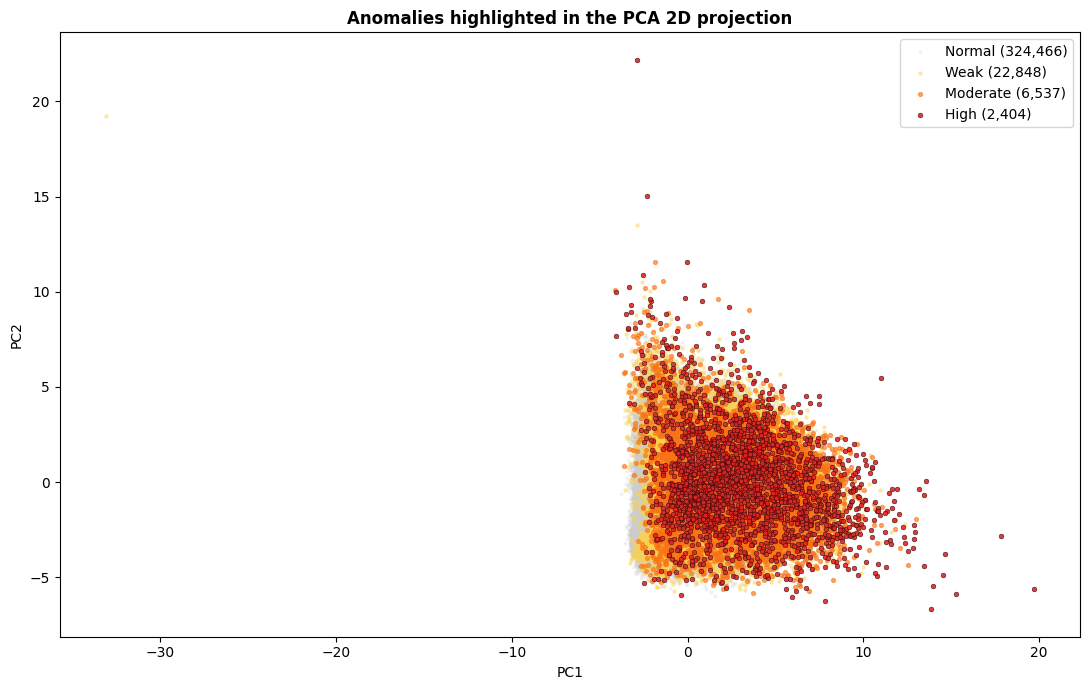

Saved pca_anomaly_sample.csv (32,182 rows for the dashboard)


In [8]:
# PCA scatter with anomalies highlighted
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
normal = merged_a_indexed[merged_a_indexed['anomaly_category']=='NORMAL']
weak = merged_a_indexed[merged_a_indexed['anomaly_category']=='WEAK_SIGNAL']
moderate = merged_a_indexed[merged_a_indexed['anomaly_category']=='MODERATE_ANOMALY']
high = merged_a_indexed[merged_a_indexed['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
ax.scatter(normal['PC1'], normal['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'Normal ({len(normal):,})')
ax.scatter(weak['PC1'], weak['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'Weak ({len(weak):,})')
ax.scatter(moderate['PC1'], moderate['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Moderate ({len(moderate):,})')
ax.scatter(high['PC1'], high['PC2'], c='#DC2626', s=12, alpha=0.9, label=f'High ({len(high):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Anomalies highlighted in the PCA 2D projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

# Export a sample for the Phase 5 dashboard (all HIGH plus a sample of the rest)
high_idx = np.where(merged_a_indexed['anomaly_category'] == 'HIGH_CONFIDENCE_ANOMALY')[0]
rng_exp = np.random.default_rng(RANDOM_SEED)
base_idx = rng_exp.choice(len(merged_a_indexed), size=min(30000, len(merged_a_indexed)), replace=False)
keep_idx = np.unique(np.concatenate([base_idx, high_idx]))
merged_a_indexed.iloc[keep_idx][['PC1', 'PC2', 'anomaly_category', 'CLUSTER_KMEANS']].to_csv(
    OUT_DIR / 'pca_anomaly_sample.csv', index=False)
print(f'Saved pca_anomaly_sample.csv ({len(keep_idx):,} rows for the dashboard)')

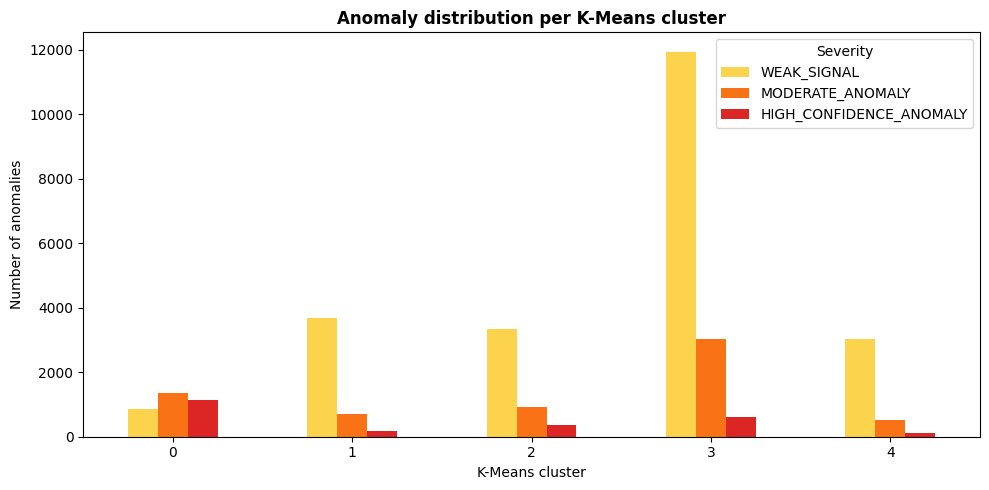

In [9]:
# Anomalies per cluster (heatmap-like bar)
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NORMAL' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NORMAL'])
cluster_anomalies_sorted = cluster_anomalies.reindex(columns=['WEAK_SIGNAL','MODERATE_ANOMALY','HIGH_CONFIDENCE_ANOMALY'])
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#DC2626'])
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('Number of anomalies')
ax.set_title('Anomaly distribution per K-Means cluster', fontweight='bold')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

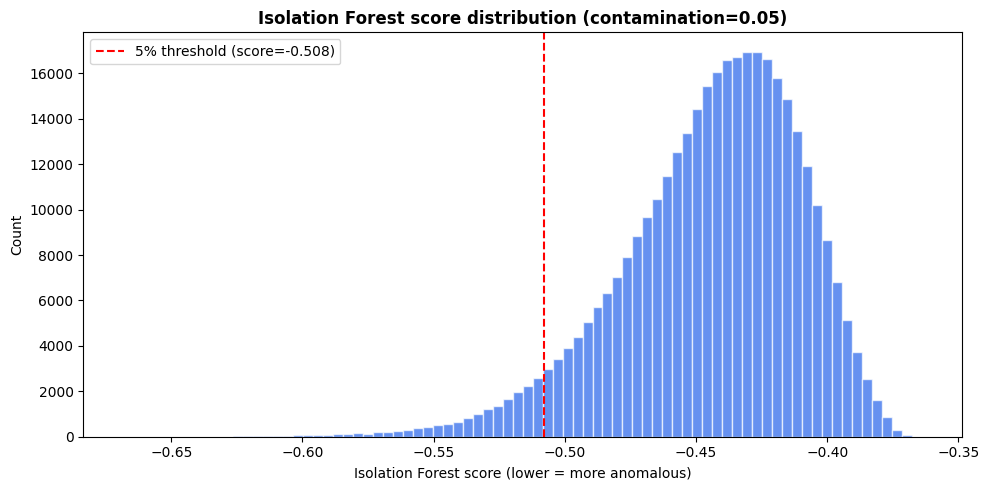

In [10]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest score (lower = more anomalous)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest score distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

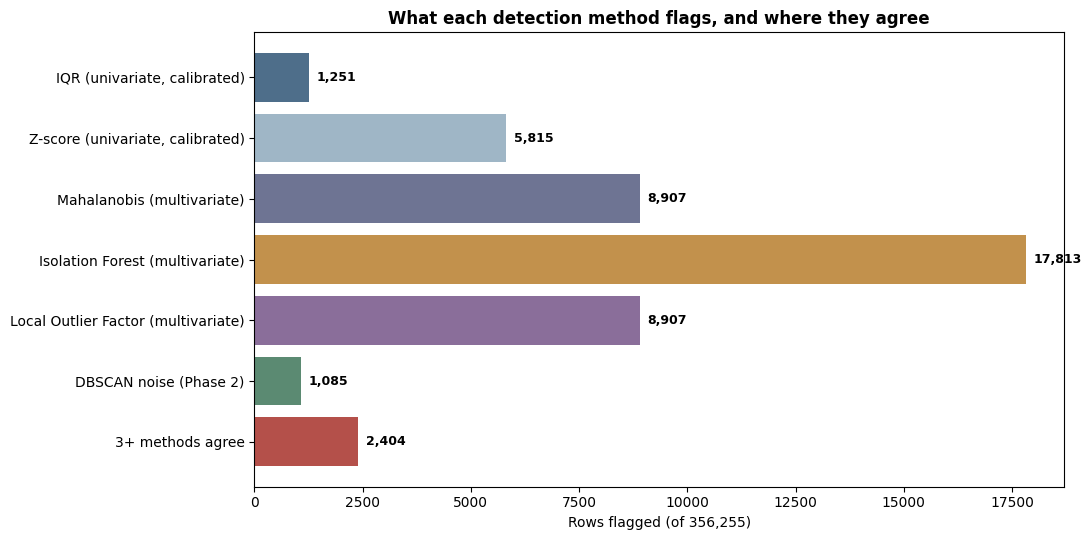

In [11]:
# Per-method comparison: how many rows each detector flags, and how many rows
# at least three of the six agree on. A six-set Venn is unreadable, so this
# stays a simple ranked bar.
method_counts = [
    ('IQR (univariate, calibrated)', int(merged_a['is_iqr_outlier'].sum()), '#4E6E8A'),
    ('Z-score (univariate, calibrated)', int(merged_a['is_zscore_outlier'].sum()), '#9FB6C6'),
    ('Mahalanobis (multivariate)', int(merged_a['is_mahalanobis_outlier'].sum()), '#6E7493'),
    ('Isolation Forest (multivariate)', int(merged_a['is_isolation_outlier'].sum()), '#C2914C'),
    ('Local Outlier Factor (multivariate)', int(merged_a['is_lof_outlier'].sum()), '#8A6E9A'),
    ('DBSCAN noise (Phase 2)', int(merged_a['IS_OUTLIER'].fillna(0).sum()), '#5B8A72'),
    ('3+ methods agree', int((merged_a['detection_count'] >= 3).sum()), '#B4504A'),
]
fig, ax = plt.subplots(figsize=(11, 5.5))
names_m = [m[0] for m in method_counts]
vals_m = [m[1] for m in method_counts]
cols_m = [m[2] for m in method_counts]
bars = ax.barh(names_m[::-1], vals_m[::-1], color=cols_m[::-1])
for bar, v in zip(bars, vals_m[::-1]):
    ax.text(v + max(vals_m)*0.01, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Rows flagged (of 356,255)')
ax.set_title('What each detection method flags, and where they agree', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()

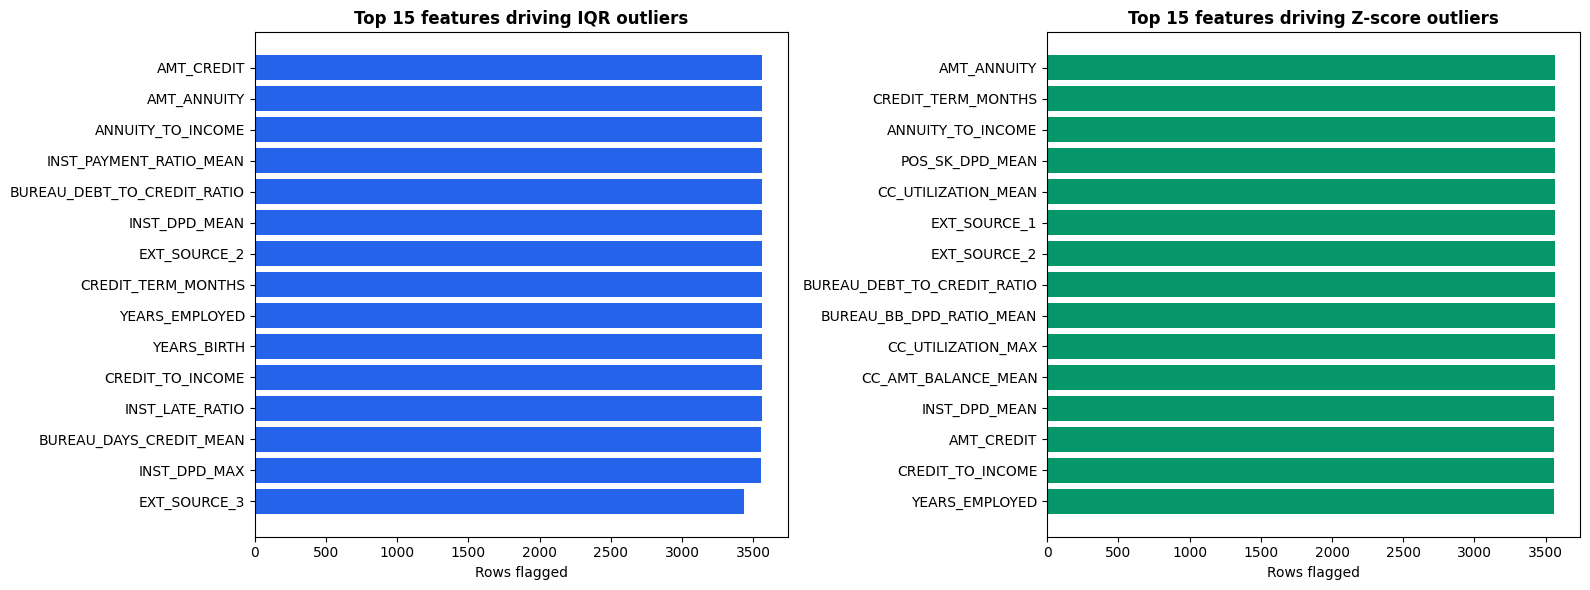

In [12]:
# Heatmap: features that drive anomalies the most
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
axes[0].set_title('Top 15 features driving IQR outliers', fontweight='bold')
axes[0].set_xlabel('Rows flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Top 15 features driving Z-score outliers', fontweight='bold')
axes[1].set_xlabel('Rows flagged')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

---
Phase 4 done. The artefacts are in `results/phase4_anomaly/`.